In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_community_distribution(csv_file, title):
    df = pd.read_csv(csv_file)
    
    plt.figure(figsize=(6,4))
    
    labels = []
    for _, row in df.iterrows():
        min_s = int(row['minSizeInBin'])
        max_s = int(row['maxSizeInBin'])
        
        if min_s == max_s:
            labels.append(f"{min_s}")
        else:
            labels.append(f"{min_s}-{max_s}")
    
    bars = plt.bar(range(len(df)), df['quantityOfCommunities'], color='teal', edgecolor='black')
    
    plt.yscale('log')
    
    plt.xticks(range(len(df)), labels, rotation=45, ha='right')
    plt.xlabel('Tamanho da comunidade (número de vértices)')
    plt.ylabel('Quantidade de comunidades (Log)')
    plt.title(f'Histograma de comunidades (escala log) - {title}')
        
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

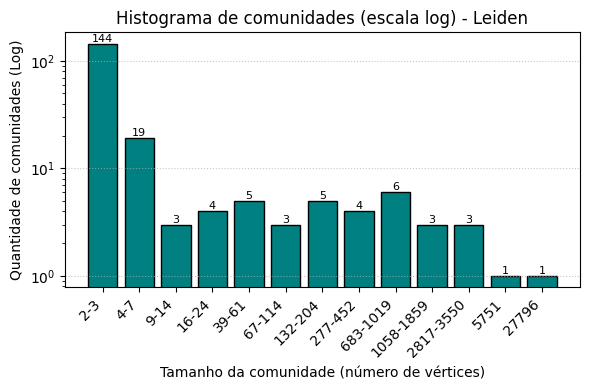

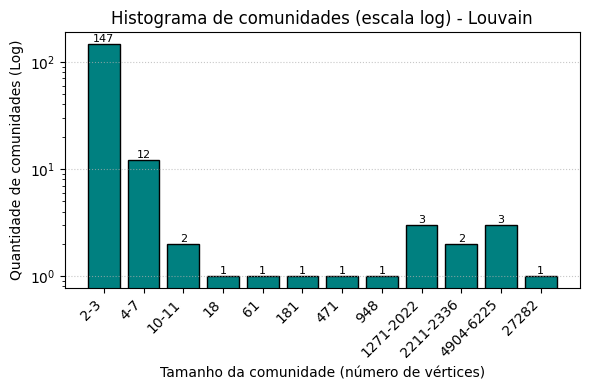

In [2]:
files = {
    "Leiden":   "analysis_data/users_graph/users_leiden.csv",
    "Louvain":  "analysis_data/users_graph/users_louvain.csv",
}

for label, path in files.items():
    plot_community_distribution(path, label)